Confusion Matrix:  [[574  37  21  19]
 [ 40 553  33  21]
 [ 12  36 639  14]
 [ 20  18  25 578]]


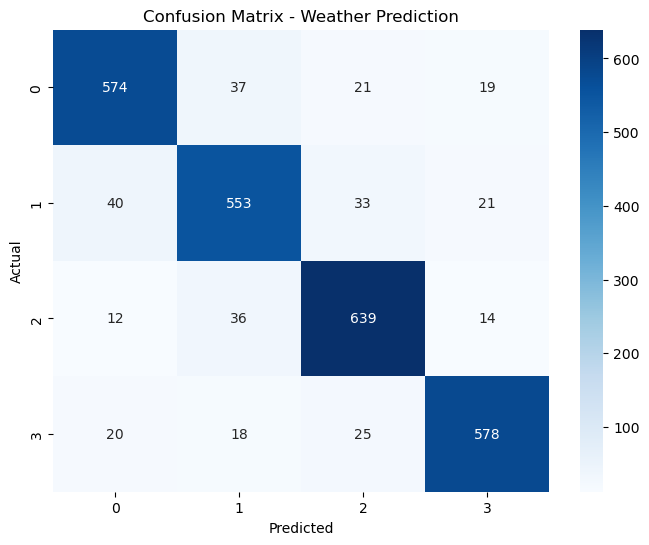

C:\Users\Acer\AppData\Local\Temp\ipykernel_13972\3730159500.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='actual_w',data=weather,palette='rainbow')


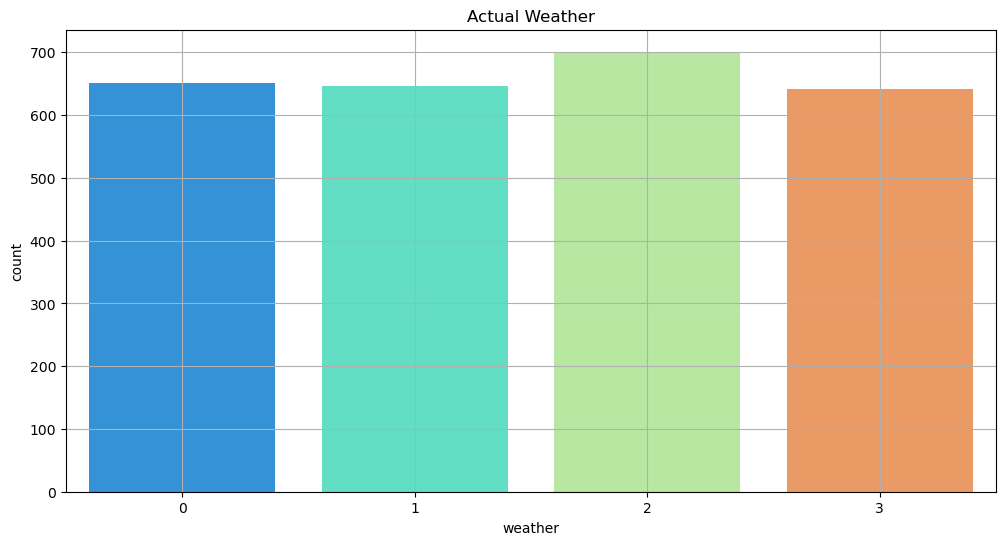

C:\Users\Acer\AppData\Local\Temp\ipykernel_13972\3730159500.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='prediction_w',data=weather,palette='rainbow')


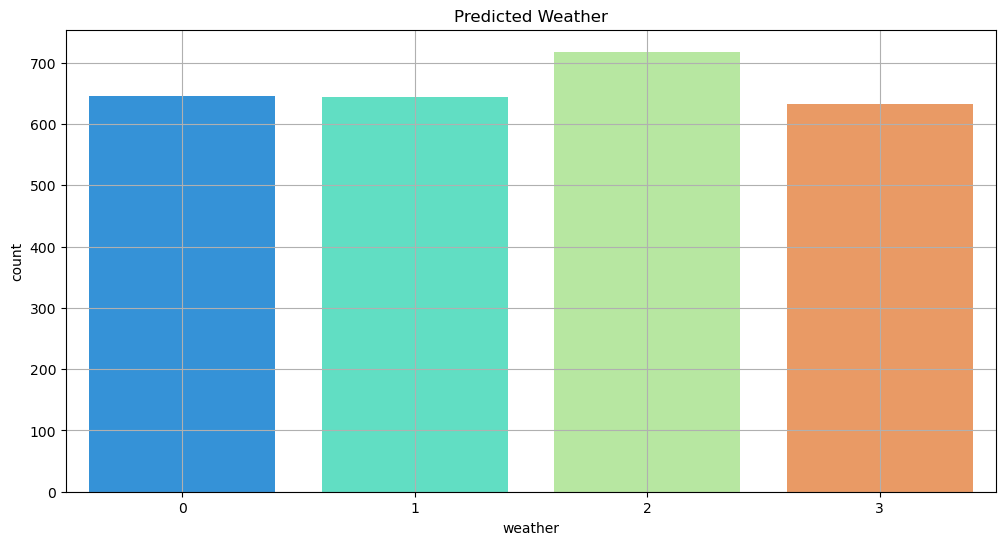

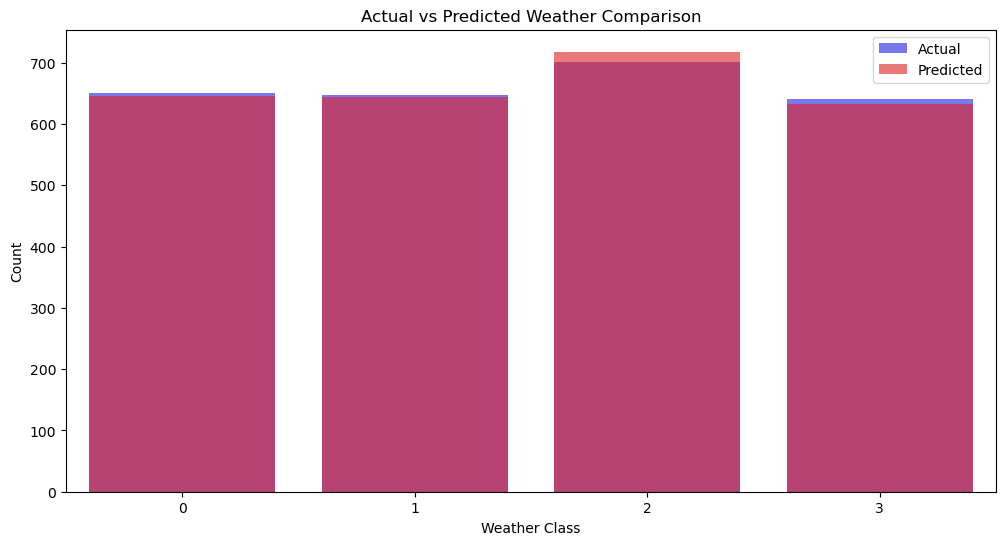

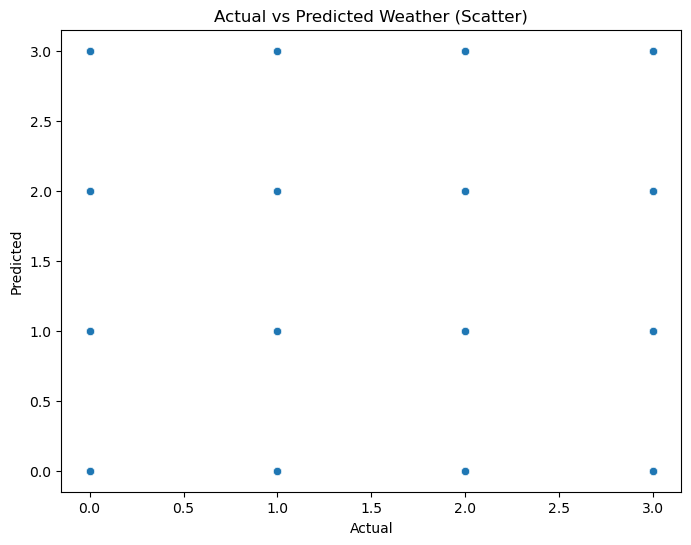

MAE  7.931640151515151
MSE  120.54960488636364
RMSE  10.97950840822865
R2  0.5951827115829041


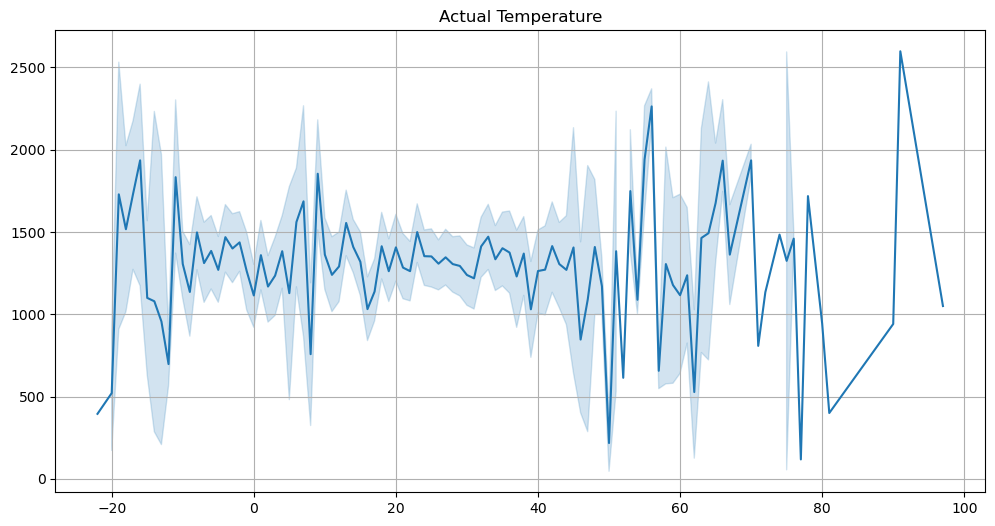

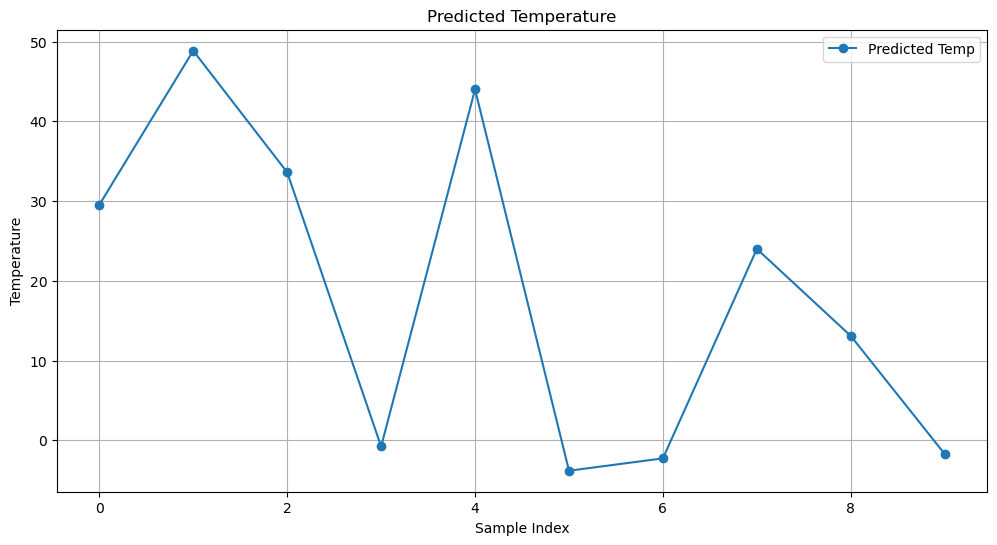

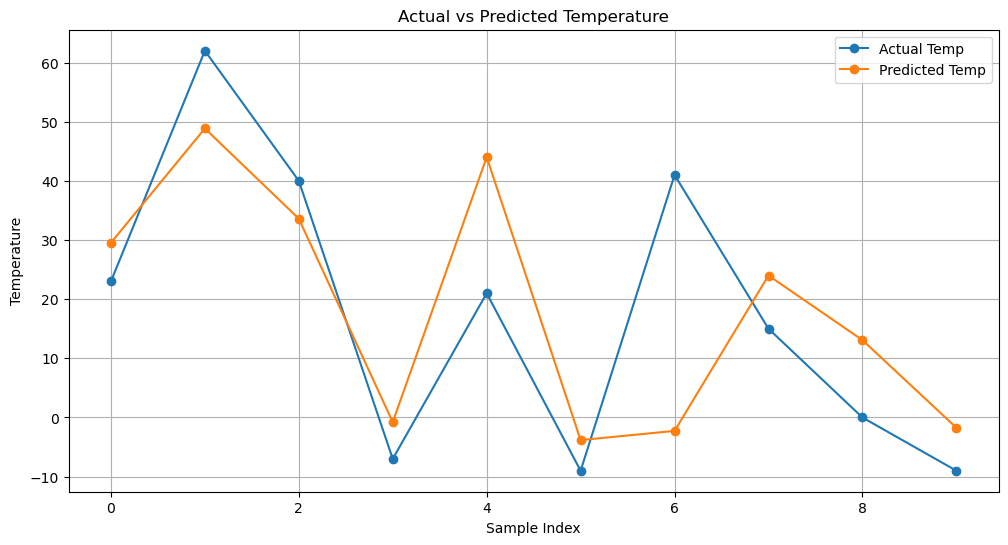

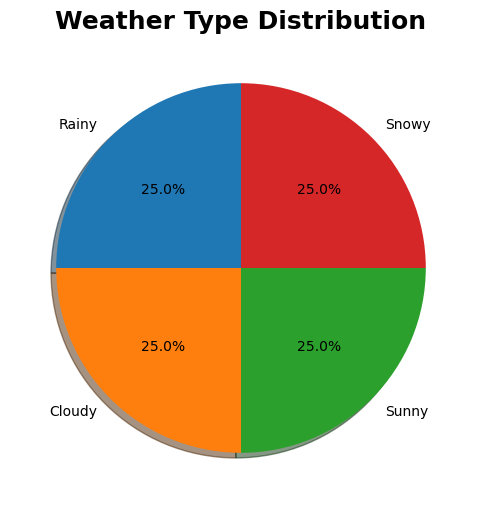


--- WEATHER PREDICTION (USER INPUT) ---


In [ ]:
# import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score,recall_score,precision_score
from sklearn.metrics import confusion_matrix

data = pd.read_csv('weather_classification_data.csv')
df = data.copy()
df = pd.DataFrame(data)
# df.info()
# df.isna()
# df.dropna()
df.head(7)

le = LabelEncoder() 
df['cloudC_e'] = le.fit_transform(df['Cloud Cover'])
df['season_e'] = le.fit_transform(df['Season'])
df['weather_e'] = le.fit_transform(df['Weather Type'])
df['location_e'] = le.fit_transform(df['Location'])

df_encode = pd.get_dummies(df, columns=['Location'])
df_encode.head()

X = df[[
    'Humidity',
    'Wind Speed',
    'Precipitation (%)',
    'cloudC_e',
    'Atmospheric Pressure',
    'UV Index',
    'season_e',
    'Visibility (km)',
    'location_e'
]]
y2 = df['Temperature']
y= df['weather_e']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X2_train,X2_test,Y2_train,Y2_test = train_test_split(X,y2,test_size=0.2,random_state=42)

dt = DecisionTreeClassifier()
dt.fit(X_train,Y_train)
y_predict = dt.predict(X_test)

rff = RandomForestRegressor( n_estimators=100,random_state=42)
rff.fit(X2_train,Y2_train)
y2_predict = rff.predict(X2_test)

cm = confusion_matrix(Y_test,y_predict)
print('Confusion Matrix: ',cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - Weather Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


weather = pd.DataFrame({
    'actual_w': Y_test.values,
    "prediction_w":y_predict
})

fig = plt.figure(figsize=(12,6),dpi=100)
sns.countplot(x='actual_w',data=weather,palette='rainbow')
plt.title('Actual Weather')
plt.xlabel('weather')
plt.ylabel('count')
plt.grid(True)
plt.show()


fig = plt.figure(figsize=(12,6),dpi=100)
sns.countplot(x='prediction_w',data=weather,palette='rainbow')
plt.title('Predicted Weather')
plt.xlabel('weather')
plt.ylabel('count')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(x='actual_w', data=weather, color='blue', label='Actual', alpha=0.6)
sns.countplot(x='prediction_w', data=weather, color='red', label='Predicted', alpha=0.6)
plt.title('Actual vs Predicted Weather Comparison')
plt.xlabel('Weather Class')
plt.ylabel('Count')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x=weather['actual_w'], y=weather['prediction_w'])
plt.title('Actual vs Predicted Weather (Scatter)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()



mae = mean_absolute_error(Y2_test,y2_predict)
mse = mean_squared_error(Y2_test,y2_predict)
rmse = np.sqrt(mse) 
r2 = r2_score(Y2_test,y2_predict)

print("MAE ",mae)
print("MSE ",mse)
print("RMSE ",rmse)
print("R2 ",r2)

temperature = pd.DataFrame({
    'actual_t': Y2_test.values,
    "prediction_t":y2_predict
})


fig = plt.figure(figsize=(12,6),dpi=100)
sns.lineplot(x='actual_t',y=temperature.index,data=temperature)
plt.title('Actual Temperature')
plt.xlabel('')
plt.ylabel('')
plt.grid(True)
plt.show()

temp_compare = temperature.head(10)

plt.figure(figsize=(12,6), dpi=100)
plt.plot(temp_compare.index,temp_compare['prediction_t'],marker='o',label='Predicted Temp')

plt.title('Predicted Temperature')
plt.xlabel('Sample Index')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)

plt.show()

temp_compare = temperature.head(10)
plt.figure(figsize=(12,6))
plt.plot(temp_compare.index,temp_compare['actual_t'],marker='o',label='Actual Temp')

plt.plot(temp_compare.index,temp_compare['prediction_t'],marker='o',label='Predicted Temp'
)

plt.title('Actual vs Predicted Temperature')
plt.xlabel('Sample Index')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)

plt.show()













weather_counts = df['Weather Type'].value_counts()
plt.figure(figsize=(12,6))
plt.pie(weather_counts,labels=weather_counts.index,autopct='%1.1f%%',shadow=True,startangle=90)
plt.title('Weather Type Distribution',fontsize=18,fontweight='bold')
plt.show()


print("\n--- WEATHER PREDICTION (USER INPUT) ---")
try:
    humidity = float(input("Enter Humidity: "))
    wind_speed = float(input("Enter Wind Speed: "))
    precipitation = float(input("Enter Precipitation (%): "))
    cloud = input("Enter Cloud Cover: ")
    pressure = float(input("Enter Atmospheric Pressure: "))
    uv = float(input("Enter UV Index: "))
    season = input("Enter Season: ")
    visibility = float(input("Enter Visibility (km): "))
    location = input("Enter Location: ")

    cloud_e = le.fit_transform([cloud])[0]
    season_e = le.fit_transform([season])[0]
    location_e = le.fit_transform([location])[0]

    user_input = np.array([[
        humidity,
        wind_speed,
        precipitation,
        cloud_e,
        pressure,
        uv,
        season_e,
        visibility,
        location_e
    ]])

    
    user_input = scaler.transform(user_input)

    
    pred_weather = dt.predict(user_input)[0]

    if pred_weather[0] == 0:
        print("Predicted Weather: Sunny ☀️")

    elif pred_weather[0] == 1:
        print("Predicted Weather: Rainy 🌧️")

    elif pred_weather[0] == 2:
        print("Predicted Weather: Cloudy ☁️")

    else:
        print("Predicted Weather: Stormy ⛈️")

except Exception as e:
    print("Input Error:", e)
    






In [2]:
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,cloudC_e,season_e,weather_e,location_e
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,3,3,1,1
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,3,1,0,1
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,0,1,3,2
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,0,1,3,0
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy,2,2,1,2
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy,1,3,2,0
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy,2,0,0,0
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy,2,3,2,1
